In [35]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [36]:

def plot_pod_temporal_modes(projectnames, labels, dt, numModes,
                           saveName="POD_temporal_modes.png",
                           scale_by_sv=False,
                           invert_signs=None):

    if len(projectnames) != len(labels):
        raise ValueError("projectnames and labels must have the same length.")

    # ---- Default: no inversion
    if invert_signs is None:
        invert_signs = [1] * len(projectnames)

    if len(invert_signs) != len(projectnames):
        raise ValueError("invert_signs must have the same length as projectnames.")

    # ---- Modify save name if scaling is enabled
    if scale_by_sv:
        saveName = "Scaled_" + saveName

    ncols = math.ceil(math.sqrt(numModes))
    nrows = math.ceil(numModes / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)

    for mode in range(1, numModes + 1):

        r = (mode-1) // ncols
        c = (mode-1) % ncols
        ax = axes[r, c]

        for proj, label, sign in zip(projectnames, labels, invert_signs):

            fname = f"{proj}_podTempMode_{mode}.txt"
            data = np.loadtxt(fname)

            # ---- Time vector
            t = dt * np.arange(len(data))

            # ---- Optional scaling by singular values
            if scale_by_sv:
                S = np.loadtxt(f"{proj}_SV.txt")

                if mode > len(S):
                    raise ValueError(f"{proj}: not enough singular values for mode {mode}")

                data = data * S[mode-1]

            # ---- Apply inversion
            data = sign * data

            ax.plot(t, data, linewidth=2, label=label)

        ax.set_title(f"POD Mode {mode}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Temporal Coefficient")
        ax.grid(True)
        ax.legend()

    # Hide unused panels
    for k in range(numModes, nrows*ncols):
        r = k // ncols
        c = k % ncols
        axes[r, c].axis("off")

    plt.tight_layout()

    plt.savefig(saveName, dpi=300, bbox_inches="tight")
    plt.show()

In [37]:
def plot_singular_value_spectra(projectnames, labels,
                                saveNameSpectrum,
                                saveNameEnergy,
                                energy_threshold=None,
                                log_x_spectrum=False,
                                log_x_energy=True,
                                trim_last_n=0,
                                sv_tol=None):

    if len(projectnames) != len(labels):
        raise ValueError("projectnames and labels must have the same length.")

    # ---- Modify filenames based on log settings
    spectrum_suffix = "LogX" if log_x_spectrum else "LinX"
    energy_suffix   = "LogX" if log_x_energy   else "LinX"

    saveNameSpectrum = f"{saveNameSpectrum.replace('.png','')}_{spectrum_suffix}.png"
    saveNameEnergy   = f"{saveNameEnergy.replace('.png','')}_{energy_suffix}.png"

    # =========================================================
    # FIGURE 1: Singular value spectrum (WITH trimming options)
    # =========================================================
    plt.figure(figsize=(6,5))

    for proj, label in zip(projectnames, labels):

        S = np.loadtxt(f"{proj}_SV.txt")

        # ---- Apply trimming ONLY to this figure
        if trim_last_n > 0:
            if trim_last_n >= len(S):
                raise ValueError(f"{proj}: trim_last_n too large.")
            S = S[:-trim_last_n]

        if sv_tol is not None:
            S = S[S > sv_tol * np.max(S)]

        x = np.arange(1, len(S)+1)

        if log_x_spectrum:
            x_plot = np.log10(x)
            xlabel = r"$\log_{10}(\text{mode index})$"
        else:
            x_plot = x
            xlabel = "Mode Index"

        plt.plot(x_plot, np.log10(S/np.max(S)), linewidth=2, label=label)

    plt.xlabel(xlabel)
    plt.ylabel(r"$\log_{10}(\sigma_i / \sigma_{max})$")
    plt.title("Singular Value Spectrum")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(saveNameSpectrum, dpi=300, bbox_inches="tight")
    plt.show()


    # =========================================================
    # FIGURE 2: Cumulative POD energy (NO trimming applied)
    # =========================================================
    plt.figure(figsize=(6,5))

    for proj, label in zip(projectnames, labels):

        S = np.loadtxt(f"{proj}_SV.txt")

        energy = S**2
        cumulative_energy = np.cumsum(energy) / np.sum(energy)

        x = np.arange(1, len(S)+1)

        if log_x_energy:
            x_plot = np.log10(x)
            xlabel = r"$\log_{10}(\text{mode index})$"
        else:
            x_plot = x
            xlabel = "Mode Index"

        plt.plot(x_plot, cumulative_energy, linewidth=2, label=label)

    if energy_threshold is not None:
        plt.axhline(energy_threshold,
                    color='red',
                    linestyle='--',
                    linewidth=2,
                    label=f"{energy_threshold*100:.1f}% energy")

    plt.xlabel(xlabel)
    plt.ylabel("Cumulative Energy Fraction")
    plt.title("Cumulative POD Energy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(saveNameEnergy, dpi=300, bbox_inches="tight")
    plt.show()

In [38]:
def plot_eigs_on_unit_circle(project_names, n=1, cmap='viridis'):
    """
    Plot complex DMD eigenvalues on the complex plane with a unit circle
    for each project name in project_names.

    Parameters
    ----------
    project_names : list[str]
        List of project name strings, e.g.
        ["Valve_0.3mm", "Valve_0.5mm", "Valve_0.75mm"].
    n : int
        Exponent for lambda in |lambda^n * b_k| (default: 1).
    cmap : str
        Colormap for points (default: 'viridis').
    """

    for project_name in project_names:
        # Load eigenvalues and modal amplitudes
        eigvals = np.loadtxt(f"{project_name}_DMDeig.txt", dtype=complex)
        b_k = np.loadtxt(f"{project_name}_bval.txt", dtype=complex)

        # Compute color values
        color_values = np.abs((eigvals**n) * b_k)

        fig, ax = plt.subplots(figsize=(6, 6))

        # Plot unit circle
        theta = np.linspace(0, 2*np.pi, 500)
        ax.plot(np.cos(theta), np.sin(theta), 'k', linewidth=2)

        # Scatter plot of eigenvalues
        sc = ax.scatter(
            eigvals.real,
            eigvals.imag,
            c=color_values,
            cmap=cmap,
            s=100,
            edgecolors='k'
        )

        # Labels and formatting
        ax.set_xlabel(r"Re($\lambda_k$)")
        ax.set_ylabel(r"Im($\lambda_k$)")
        ax.set_aspect('equal', adjustable='box')

        # Colorbar
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(r"$|\lambda_k^n b_k|$")

        # Optional title
        ax.set_title(f"{project_name} DMD Eigenvalues")

        # Save figure
        plt.savefig(f"{project_name}_DMDeigplot.png", dpi=300, bbox_inches='tight')

        plt.show()

In [39]:
def plot_bending_rigidity_vs_entropy(
    h,
    E,
    nu,
    R,
    L,
    Pmax,
    Pout,
    labels,
    outfile_base,
    entropy_mode="both",
    logx=False,
    pod_file="ShannonEntropy_POD.txt",
    dmd_file="ShannonEntropy_DMD.txt",
):
    """
    Plot normalized bending rigidity versus Shannon entropy.

    Parameters
    ----------
    h : array-like
        Thickness values in cm, e.g. [0.03, 0.05, 0.075].
    E : float
        Young's modulus in kPa.
    nu : float
        Poisson ratio.
    R : float
        Radius in cm.
    L : float
        Length in cm.
    Pmax : float
        Maximum pressure in kPa.
    Pout : float
        Outlet pressure in kPa.
    labels : list of str
        Labels for each case, same length as h.
    outfile_base : str
        Base name for output figure(s), e.g. "BendingRigidityVsEntropy".
        Saved files will become:
            outfile_base_POD.png
            outfile_base_DMD.png
    entropy_mode : str, optional
        "POD", "DMD", or "both".
    logx : bool, optional
        If True, plot log10(normalized bending rigidity) on x-axis.
        If False, plot linear normalized bending rigidity.
    pod_file : str, optional
        File containing POD Shannon entropy values.
    dmd_file : str, optional
        File containing DMD Shannon entropy values.
    """

    # --------------------------
    # Basic checks and setup
    # --------------------------
    h = np.asarray(h, dtype=float)

    if len(labels) != len(h):
        raise ValueError("labels must have the same length as h")

    deltaP = Pmax - Pout
    if deltaP == 0:
        raise ValueError("Pmax - Pout must be nonzero")

    # Flexural rigidity
    EB = E * h**3 / (12.0 * (1.0 - nu**2))

    # Nondimensional bending rigidity
    EB_star = EB / (deltaP * R**4 / L)

    if logx:
        if np.any(EB_star <= 0):
            raise ValueError("All nondimensionalized bending rigidities must be positive for log scaling")
        xvals = np.log10(EB_star)
        xlabel = r"$\log_{10}(E_B^*)$"
    else:
        xvals = EB_star
        xlabel = r"$E_B^*$"

    # Distinct colors for cases
    case_colors = ["blue", "orange", "green", "red", "purple", "orange", "brown"]
    if len(h) > len(case_colors):
        raise ValueError("Add more colors to case_colors to support this many cases")

    def make_single_plot(entropy_vals, mode_name, outfile_name):
        """
        Make and save one figure.
        """
        entropy_vals = np.atleast_1d(entropy_vals)

        if len(entropy_vals) != len(h):
            raise ValueError(f"{mode_name} entropy file must contain the same number of entries as h")

        fig, ax = plt.subplots(figsize=(8, 6))

        # Axis style similar to your example figure
        ax.tick_params(direction="in", top=True, right=True, length=10, width=1.2, labelsize=16)
        for spine in ax.spines.values():
            spine.set_linewidth(1.8)

        ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.7)

        # Plot each case in a different color
        for i, (xi, yi, lab) in enumerate(zip(xvals, entropy_vals, labels)):
            ax.scatter(
                xi,
                yi,
                s=110,
                color=case_colors[i],
                zorder=3
            )
            ax.text(
                xi,
                yi,
                f" {lab}",
                fontsize=16,
                va="center",
                ha="left",
                color=case_colors[i]
            )

        ax.set_xlabel(xlabel, fontsize=22, labelpad=10)
        ax.set_ylabel("Global Entropy", fontsize=22, labelpad=10)

        xmin, xmax = np.min(xvals), np.max(xvals)
        xpad = 0.08 * (xmax - xmin) if xmax > xmin else 0.05 * xmax
        ax.set_xlim(xmin - xpad, xmax + 3 * xpad)

        plt.tight_layout()
        plt.savefig(outfile_name, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {outfile_name}")
        plt.show()

    # --------------------------
    # Make requested plot(s)
    # --------------------------
    mode_upper = entropy_mode.upper()

    if mode_upper == "POD":
        H_pod = np.loadtxt(pod_file)
        make_single_plot(H_pod, "POD", f"{outfile_base}_POD.png")

    elif mode_upper == "DMD":
        H_dmd = np.loadtxt(dmd_file)
        make_single_plot(H_dmd, "DMD", f"{outfile_base}_DMD.png")

    elif mode_upper == "BOTH":
        H_pod = np.loadtxt(pod_file)
        H_dmd = np.loadtxt(dmd_file)

        make_single_plot(H_pod, "POD", f"{outfile_base}_POD.png")
        make_single_plot(H_dmd, "DMD", f"{outfile_base}_DMD.png")

    else:
        raise ValueError("entropy_mode must be 'POD', 'DMD', or 'both'")




Saved figure to BendingRigidityVsEntropy_POD.png


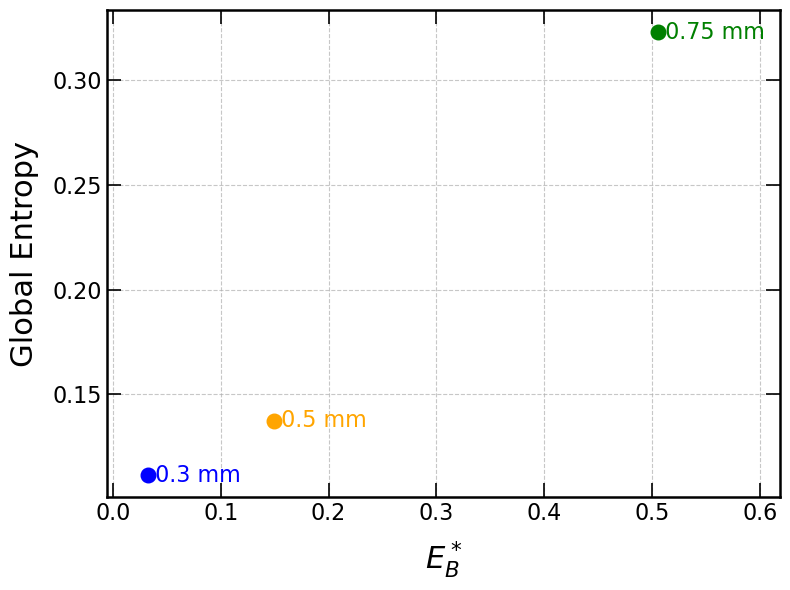

In [40]:
if __name__ == "__main__":
    # POD Plots
    # plot_pod_temporal_modes(["Valve_0.3mm", "Valve_0.5mm", "Valve_0.75mm"], ["0.3 mm", "0.5 mm", "0.75 mm"], 0.008, 4, saveName="POD_temporal_modes.png", scale_by_sv=True, invert_signs=[-1, -1, -1])
    # plot_singular_value_spectra(["Valve_0.3mm", "Valve_0.5mm", "Valve_0.75mm"], ["0.3 mm", "0.5 mm", "0.75 mm"],
    #                             saveNameSpectrum="SV_Spectrum_Valve.png",
    #                             saveNameEnergy="SVcumu_Energy_Valve.png",
    #                             energy_threshold=0.98,
    #                             log_x_spectrum=True,
    #                             log_x_energy=False,
    #                             trim_last_n=2,
    #                             sv_tol=None)

    # DMD Plots
    #plot_eigs_on_unit_circle(["Valve_0.3mm", "Valve_0.5mm", "Valve_0.75mm"], n=1, cmap='viridis') # Not tested yet!

    # Shannon Entropy Plots
    plot_bending_rigidity_vs_entropy(
        h=[0.03, 0.05, 0.075],
        E=2000,
        nu=0.4,
        R=1.12,
        L=19,
        Pmax=2,
        Pout=0,
        labels=["0.3 mm", "0.5 mm", "0.75 mm"],
        outfile_base="BendingRigidityVsEntropy",
        entropy_mode="POD",   # "POD", "DMD", or "both"
        logx=False             # True or False
    )
    